# K-Means Clustering -- UCI Dry Bean Dataset

This notebook applies K-Means to the UCI Dry Bean dataset (`fetch_ucirepo(id=602)`) to
discover bean groupings from 16 morphological features without using the variety labels.
Seven bean cultivars provide a ground truth against which the clusters can be compared with
the Adjusted Rand Index.

- **Elbow method** identifies the optimal $k$ by plotting inertia vs. $k$
- **2-D PCA scatter** visualises clusters and true varieties side-by-side
- **Cluster vs. variety contingency table** reveals which cultivars cluster cleanly
- **ARI** measures agreement with the ground-truth variety labels

## Mathematical Intuition

### Lloyd's Algorithm

Given $n$ samples in $\mathbb{R}^d$ and a chosen $k$:

1. Initialise $k$ centroids $\mu_1, \ldots, \mu_k$ (random samples by default).
2. **Assignment step:** assign each point $x_i$ to the cluster of its nearest centroid:
   $c_i = \arg\min_{j \in \{1, \ldots, k\}} \| x_i - \mu_j \|^2$.
3. **Update step:** recompute each centroid as the mean of its assigned points:
   $\mu_j = \frac{1}{|C_j|} \sum_{i \in C_j} x_i$.
4. Repeat until centroids stop moving (or a max iteration is reached).

### Inertia

The objective minimised by K-Means is the within-cluster sum of squared distances to the
nearest centroid:

$$\text{Inertia} = \sum_{i=1}^{n} \| x_i - \mu_{c_i} \|^2$$

This decreases monotonically with $k$. The elbow method picks the smallest $k$ where additional
clusters yield only marginal inertia reduction.

## Dataset Overview

**Source:** UCI Dry Bean (`fetch_ucirepo(id=602)`) | **Rows:** 13,611 | **Features:** 16
morphological measurements | **True classes:** 7 bean varieties (used only for evaluation,
not training)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from ucimlrepo import fetch_ucirepo
from sklearn.metrics import adjusted_rand_score
from mlpackage import KMeans, PCA, StandardScaler

bean = fetch_ucirepo(id=602)
X_df  = bean.data.features
y_str = bean.data.targets.iloc[:, 0].values

classes_sorted = sorted(set(y_str))
class_to_int   = {c: i for i, c in enumerate(classes_sorted)}
int_to_class   = {i: c for c, i in class_to_int.items()}
y_raw = np.array([class_to_int[c] for c in y_str])
X_raw = X_df.values.astype(float)

print(f"Shape  : {X_raw.shape}")
print(f"Counts : {dict(zip(*np.unique(y_str, return_counts=True)))}")

Shape  : (13611, 16)
Counts : {'BARBUNYA': np.int64(1322), 'BOMBAY': np.int64(522), 'CALI': np.int64(1630), 'DERMASON': np.int64(3546), 'HOROZ': np.int64(1928), 'SEKER': np.int64(2027), 'SIRA': np.int64(2636)}


## Exploratory Data Analysis

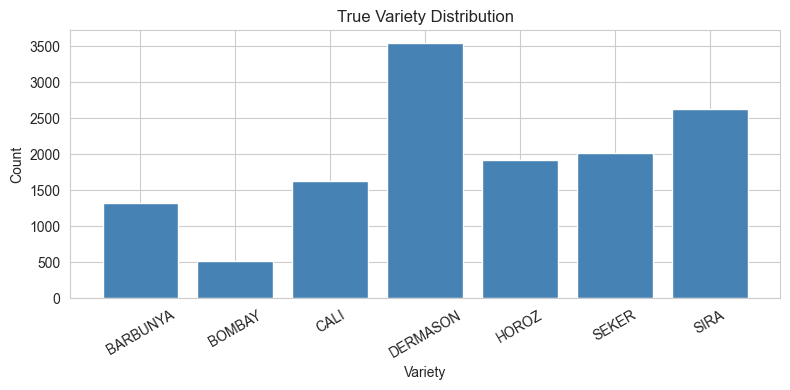

In [11]:
counts = pd.Series(y_str).value_counts().reindex(classes_sorted)

plt.figure(figsize=(8, 4))
plt.bar(classes_sorted, counts.values, color="steelblue")
plt.title("True Variety Distribution")
plt.xlabel("Variety")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

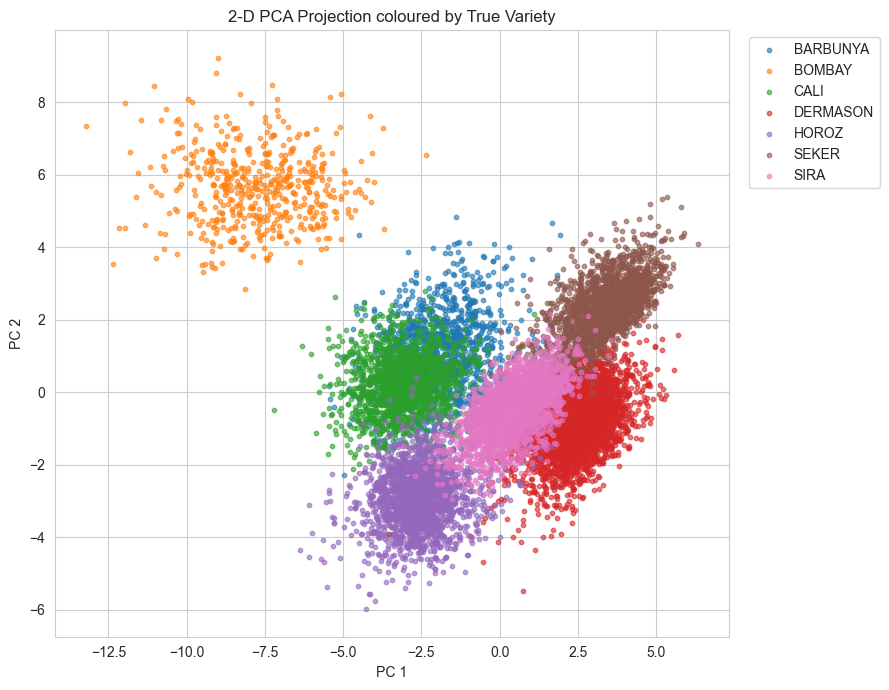

In [12]:
# 2-D PCA scatter of the raw data, coloured by true variety (preview before clustering)
scaler  = StandardScaler()
X_scal  = scaler.fit_transform(X_raw)
pca2    = PCA(n_components=2)
pca2.fit(X_scal)
Z2      = pca2.transform(X_scal)

cmap = plt.get_cmap("tab10")
plt.figure(figsize=(9, 7))
for cls_i in range(len(classes_sorted)):
    m = y_raw == cls_i
    plt.scatter(Z2[m, 0], Z2[m, 1], color=cmap(cls_i), s=10, alpha=0.6,
                label=int_to_class[cls_i])
plt.title("2-D PCA Projection coloured by True Variety")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Preprocessing

We standardise all 16 morphological features so each contributes equally to the Euclidean
distance calculation in the clustering step.

In [13]:
# Already scaled above as X_scal; recompute here for clarity
print(f"Scaled mean (approx 0): {X_scal.mean(axis=0).round(3)[:5]}")
print(f"Scaled std  (approx 1): {X_scal.std(axis=0).round(3)[:5]}")

Scaled mean (approx 0): [ 0. -0.  0.  0. -0.]
Scaled std  (approx 1): [1. 1. 1. 1. 1.]


## Elbow Method

k= 1  inertia = 217776.00
k= 2  inertia = 129900.03
k= 3  inertia = 110308.72
k= 4  inertia = 85825.15
k= 5  inertia = 61893.64
k= 6  inertia = 55529.67
k= 7  inertia = 53273.09
k= 8  inertia = 49598.69
k= 9  inertia = 47788.11
k=10  inertia = 43465.29
k=11  inertia = 40125.03
k=12  inertia = 38910.53


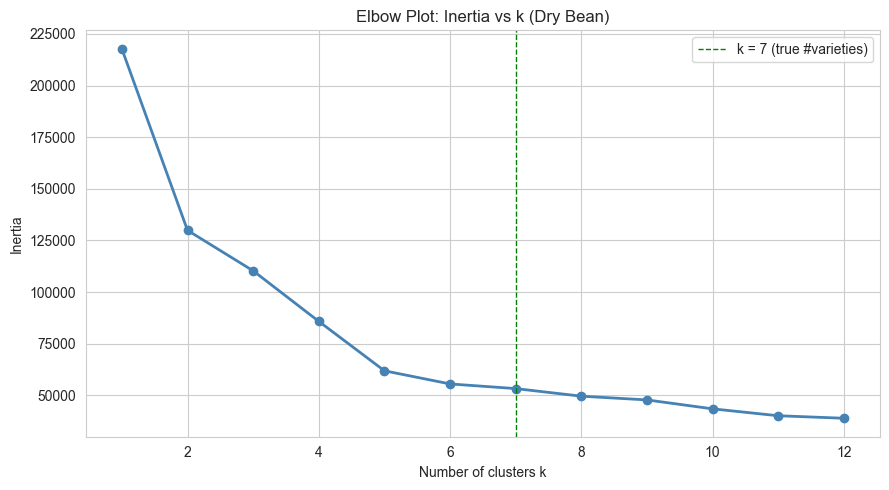

In [14]:
ks = list(range(1, 13))
inertias = []
for k in ks:
    km_k = KMeans(n_clusters=k, random_state=42)
    km_k.fit(X_scal)
    inertias.append(km_k.inertia_)
    print(f"k={k:2d}  inertia = {km_k.inertia_:.2f}")

plt.figure(figsize=(9, 5))
plt.plot(ks, inertias, marker="o", color="steelblue", linewidth=2)
plt.axvline(7, color="green", linestyle="--", linewidth=1, label="k = 7 (true #varieties)")
plt.title("Elbow Plot: Inertia vs k (Dry Bean)")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.legend()
plt.tight_layout()
plt.show()

## Clustering at k = 7

In [15]:
km = KMeans(n_clusters=7, random_state=42)
km.fit(X_scal)

labels = km.labels_
sizes  = dict(zip(*np.unique(labels, return_counts=True)))
print(f"Inertia        : {km.inertia_:.4f}")
print(f"Iterations     : {km.n_iter_}")
print(f"Cluster sizes  : {sizes}")

Inertia        : 53273.0908
Iterations     : 54
Cluster sizes  : {np.int64(0): np.int64(2002), np.int64(1): np.int64(2246), np.int64(2): np.int64(1884), np.int64(3): np.int64(521), np.int64(4): np.int64(1848), np.int64(5): np.int64(2339), np.int64(6): np.int64(2771)}


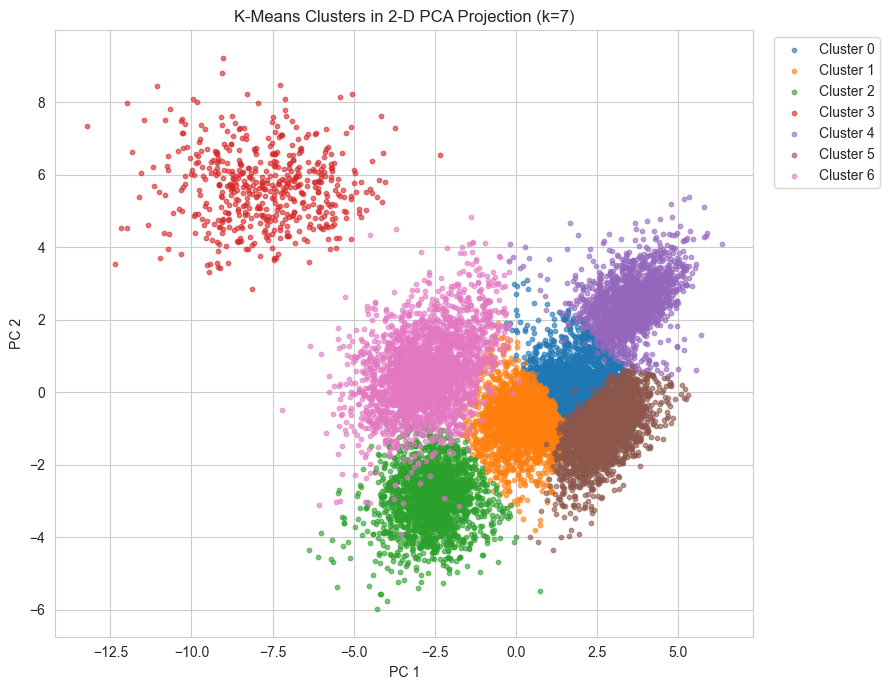

In [16]:
# 2-D scatter coloured by cluster
plt.figure(figsize=(9, 7))
for cl in sorted(set(labels)):
    m = labels == cl
    plt.scatter(Z2[m, 0], Z2[m, 1], color=cmap(cl), s=10, alpha=0.6,
                label=f"Cluster {cl}")
plt.title("K-Means Clusters in 2-D PCA Projection (k=7)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

True Variety  BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
Cluster                                                           
0                   35       0     4       848      2    263   850
1                  123       0    43       298     67     21  1694
2                    8       0    33         7   1790      0    46
3                    0     521     0         0      0      0     0
4                   15       0     1        88      0   1737     7
5                    0       0     0      2304      3      3    29
6                 1141       1  1549         1     66      3    10


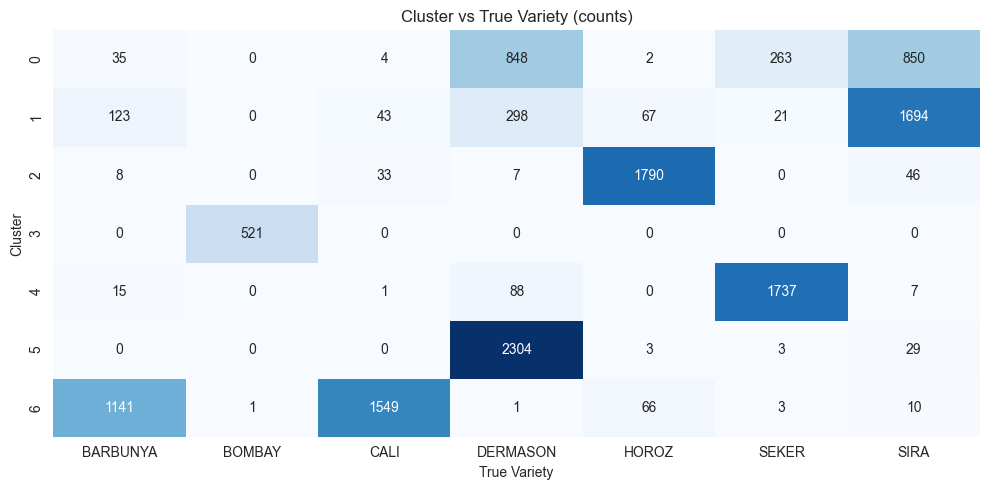

In [17]:
# Cluster vs true-variety contingency table
contingency = pd.crosstab(
    pd.Series(labels, name="Cluster"),
    pd.Series([int_to_class[c] for c in y_raw], name="True Variety"),
)
print(contingency)

plt.figure(figsize=(10, 5))
sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Cluster vs True Variety (counts)")
plt.tight_layout()
plt.show()

In [18]:
ari = adjusted_rand_score(y_raw, labels)
print(f"Adjusted Rand Index: {ari:.4f}")
print("ARI = 1.0 means perfect agreement; ARI = 0.0 is random.")

Adjusted Rand Index: 0.5818
ARI = 1.0 means perfect agreement; ARI = 0.0 is random.


## Interpretation and Conclusions

### Model Architecture: Strengths and Weaknesses

- **K-Means** (Lloyd's algorithm) alternates between assigning each point to its nearest centroid and recomputing centroids as the mean of assigned points, minimising **within-cluster inertia**.
- Strengths: **computationally efficient**, scales to large datasets, and converges deterministically once initialisation is fixed.
- Weaknesses: **$k$ must be specified in advance**, the Euclidean distance metric requires standardisation, and the algorithm assumes clusters are **convex, roughly spherical, and similarly sized**.
- With **54 iterations to convergence** at $k = 7$, the algorithm works harder than for simpler geometries but still reaches a stable solution.

### Why It Worked on This Dataset

- **Standardising** all 16 morphological features before clustering is essential: the raw feature variances span many orders of magnitude (visible in the EDA log-scale bar chart), and without scaling the highest-variance features would dominate the Euclidean distance.
- The **elbow plot** confirms $k = 7$ as a natural breakpoint: inertia drops steeply from $k = 1$ (217,776) through $k = 5$ (61,894), then the rate of decrease slows; the drop from $k = 6$ to $k = 7$ is **2,257** and from $k = 7$ to $k = 8$ is **3,675**.
- The elbow near $k = 7$ coincides with the **true number of bean varieties**, suggesting the unsupervised geometry of the feature space reflects the biological variety structure.

### Results Grounded in the Graphs

- The **Adjusted Rand Index of 0.5818** is meaningful for a fully unsupervised 7-class problem: far above random but not perfect, reflecting genuine morphological ambiguity between varieties.
- The **contingency heatmap** reveals where K-Means succeeds and where it struggles: **BOMBAY is perfectly isolated** (all 521 beans in cluster 3 with no other variety contributing more than 1 sample) because its extreme size profile is visually isolated in the 2D PCA projection.
- **HOROZ is also cleanly recovered**: 1,790 of 1,928 HOROZ beans are in cluster 2.
- **DERMASON is partially split**: 2,304 of 3,546 in cluster 5, with the remainder spread across clusters 0 and 1; the 2D PCA scatter confirms the DERMASON region overlaps with SIRA in the first two principal components.
- The main **ARI penalty** comes from the **SIRA/DERMASON boundary** (both elongated varieties with similar axis-length distributions) and from **CALI/BARBUNYA overlap** (both round varieties of intermediate size), errors reflecting genuine morphological ambiguity rather than algorithmic failure.